In [17]:
import numpy as np
import matplotlib.pyplot as plt


In [18]:
import pandas as pd

df = pd.read_csv("H2_atmosphere_1_M_earth_1_F_earth - H2_atmosphere_1_M_earth_1_F_earth.csv")

rho_H2_1M_1F = df["Density [kg/m3]"].tolist()
rho_H2_1M_1F = np.array(rho_H2_1M_1F)

In [19]:
# R = 8.31446 # J/K/mol

# def rho_atm(P, mmw, R, T):
#     """"""
#     rho = (P*mmw) / (R*T)
    
#     return rho

# formula unneeded, gives rho_atmosphere.

# H2 atmosphere

M_1E = 5.97e25 # kg
R_1E = 1.185006e11 # km

M_10E = 5.97e24 # kg
R_10E = 6.311626946e9 # km


# R = 6378 # radius earth [km]
# M_planet = 5.98e24 # mass earth [kg]
h = 8.5 # scaleheight earth [km]
M_atm = 5.15e18 # earth atmosphere mass [kg]
M0 = M_atm
# rho_0 = 1.293e9 # density at earth surface [kg/km^3]
rho = 2e12 # density of planetesimal [kg/km^3]




# QUESTION: R_obs or R_int


# CO2 atmosphere:

In [20]:
def rho_atmos(filename):
    """"""
    df = pd.read_csv(filename)
    
    df["Density [kg/m3]"].tolist()

In [21]:

N_0 = 1 # impactor flux
r_0 = 1 # impactor radius 

def dM_atmos(q, C, R, rho_0):
    """Atmospheric mass loss through impactors"""
    if q >= 3:
        r_min = (3*rho_0/rho)**(1/3)*h
        m_min = 4*np.pi*rho_0*h**3
        
        dM = - np.pi * R**2 * ((N_0*m_min)/(q-3)) * (r_min/r_0)**(-q+1)
        
    elif 3 > q > 1:
        r_cap = (3*np.sqrt(2*np.pi)*rho_0 / (4*rho))**(1/3) * (h*R)**(1/2)
        M_cap = 2*np.pi*rho_0*(h**2)*R
        
        dM = - np.pi * R**2 * C * N_0 * M_cap * (r_cap/r_0)**(-q+1)
        
    return dM


In [22]:
q = [4.5, 4.0, 3.5, 3.1, 2.8, 2.5, 2.0, 1.5] # 4.5
C = [None, None, None, None, 2.8, 1.9, 1.3, 1.1] # None

# q = [2.8, 2.5, 2.0, 1.5] # 4.5
# C = [2.8, 1.9, 1.3, 1.1] # None

dM_list = []

for i in range(len(q)):
    dM = dM_atmos(q[i], C[i], R_1E, rho_H2_1M_1F)
    print(dM)
    dM_list.append(dM)
    
dM = np.array(dM_list)


[-4.32511832e+38 -3.91935418e+38 -3.55164391e+38 -3.21726098e+38
 -2.91359082e+38 -2.64022204e+38 -2.39713218e+38 -2.18366313e+38
 -1.98500632e+38 -1.80297792e+38 -1.63743934e+38 -1.48660832e+38
 -1.34843521e+38 -1.22237675e+38 -1.10836234e+38 -1.00765604e+38
 -9.16051747e+37 -8.33177515e+37 -7.58039756e+37 -6.88500886e+37
 -6.25888181e+37 -5.68950925e+37 -5.17803785e+37 -4.71159713e+37
 -4.28743470e+37 -3.89456334e+37 -3.52186491e+37 -3.17353208e+37
 -2.86260148e+37 -2.58537042e+37 -2.33603671e+37 -2.11407906e+37
 -1.91796639e+37 -1.74650407e+37 -1.60189062e+37 -1.48116905e+37
 -1.37447114e+37 -1.27564724e+37 -1.18342775e+37 -1.09734454e+37
 -1.01699257e+37 -9.42007548e+36 -8.72056302e+36 -8.06832633e+36
 -7.46056762e+36 -6.89475313e+36 -6.36926219e+36 -5.89381941e+36
 -5.45068005e+36 -5.03091918e+36 -4.63792295e+36]
[-3.69580949e+35 -3.69580949e+35 -3.69580949e+35 -3.69580949e+35
 -3.69580949e+35 -3.69580949e+35 -3.69580949e+35 -3.69580949e+35
 -3.69580949e+35 -3.69580949e+35 -3.6958

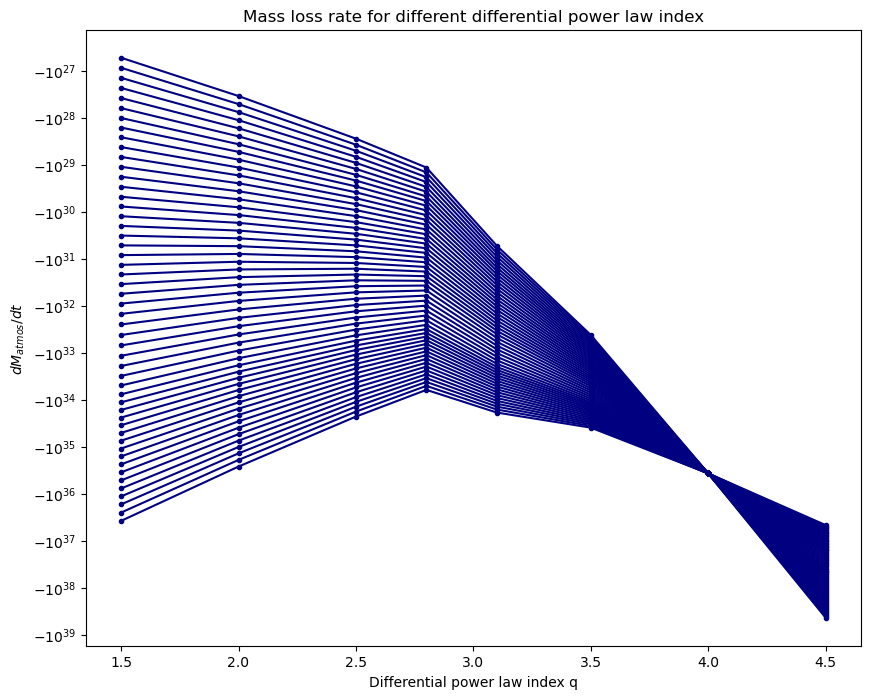

In [24]:
plt.figure(figsize=(10,8))
plt.plot(q, dM, color='navy', marker='.')
plt.xlabel('Differential power law index q')
plt.ylabel(r'$dM_{atmos}/dt$')
plt.title(r'Mass loss rate for different differential power law index')
plt.yscale('symlog')
# plt.legend()
# plt.savefig('Mtotal_vs_impactor_rad')
plt.show()
